**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 05 - Vectores y matrices: operaciones para transformar datos**

## Complemento

Este notebook se complementa con la presentación: **Algebra_Lineal.pdf**

Te recomendamos leer el PDF para trabajar con este notebook y tener una mejor comprensión de los conceptos teóricos.

¿Qué vamos a poder hacer?

🔍 Detectar y filtrar información relevante, como productos con bajo stock, categorías más frecuentes o proveedores más importantes.

🧮 Realizar operaciones con matrices en Python y entender cómo aplicarlas en contextos reales.

🧩 Construir e interpretar el modelo insumo-producto de Leontief, entendiendo cómo interactúan los sectores productivos de una economía.

🏗️ Diseñar y resolver problemas organizacionales simples a partir de data estructurada.

## Objetivos de la clase

- Entender por qué NumPy existe y cuándo conviene sobre una lista de Python
- Operar con vectores y matrices **sin escribir un solo bucle** (vectorización)
- Leer una tabla como matriz: `shape`, filas, columnas y el famoso `axis`
- Distinguir el producto **elemento a elemento** del **producto matricial**
- Reconocer qué modela cada estructura especial (diagonal, triangular, simétrica)

In [1]:
!pip install numpy matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [2]:
#importamos las librerías que vamos a usar en esta ocasión
import numpy as np
import pandas as pd



---
## 📏 Primero lo primero: ¿qué es un vector?

Antes de operar conviene tener clarísimo **qué son** estas dos cosas, porque el resto de la clase se
apoya entero acá.

Un **vector** es simplemente **una lista ordenada de números**. Nada más que eso. Lo que lo hace útil
es que esos números **van juntos y el orden significa algo**.

<svg viewBox="0 0 720 260" width="100%" style="max-width:720px">
  <!-- Panel izquierdo: la flecha -->
  <text x="20" y="24" font-size="14" font-weight="bold" fill="#2563eb">Como flecha (geometría)</text>
  <line x1="40" y1="220" x2="300" y2="220" stroke="#94a3b8" stroke-width="2"/>
  <line x1="40" y1="220" x2="40"  y2="50"  stroke="#94a3b8" stroke-width="2"/>
  <defs>
    <marker id="punta" markerWidth="10" markerHeight="8" refX="9" refY="4" orient="auto">
      <polygon points="0 0, 10 4, 0 8" fill="#2563eb"/>
    </marker>
  </defs>
  <line x1="40" y1="220" x2="230" y2="90" stroke="#2563eb" stroke-width="3" marker-end="url(#punta)"/>
  <line x1="40" y1="220" x2="230" y2="220" stroke="#cbd5e1" stroke-width="2" stroke-dasharray="4"/>
  <line x1="230" y1="220" x2="230" y2="90" stroke="#cbd5e1" stroke-width="2" stroke-dasharray="4"/>
  <text x="130" y="240" font-size="13" fill="#64748b">3 unidades</text>
  <text x="240" y="160" font-size="13" fill="#64748b">2 unidades</text>
  <text x="150" y="120" font-size="15" font-weight="bold" fill="#2563eb">v = [3, 2]</text>

  <!-- Panel derecho: la lista -->
  <text x="400" y="24" font-size="14" font-weight="bold" fill="#059669">Como lista de datos (lo nuestro)</text>
  <text x="400" y="56" font-size="13" fill="#64748b">Ventas de la semana, por día:</text>
  <g font-size="14" text-anchor="middle">
    <rect x="400" y="72" width="60" height="42" fill="#ecfdf5" stroke="#059669" stroke-width="2"/>
    <rect x="460" y="72" width="60" height="42" fill="#ecfdf5" stroke="#059669" stroke-width="2"/>
    <rect x="520" y="72" width="60" height="42" fill="#ecfdf5" stroke="#059669" stroke-width="2"/>
    <rect x="580" y="72" width="60" height="42" fill="#ecfdf5" stroke="#059669" stroke-width="2"/>
    <text x="430" y="99" fill="#065f46">120</text>
    <text x="490" y="99" fill="#065f46">95</text>
    <text x="550" y="99" fill="#065f46">145</text>
    <text x="610" y="99" fill="#065f46">80</text>
    <text x="430" y="132" font-size="12" fill="#64748b">lun</text>
    <text x="490" y="132" font-size="12" fill="#64748b">mar</text>
    <text x="550" y="132" font-size="12" fill="#64748b">mié</text>
    <text x="610" y="132" font-size="12" fill="#64748b">jue</text>
  </g>
  <text x="400" y="172" font-size="13" fill="#334155">El orden importa: si mezclás las columnas,</text>
  <text x="400" y="192" font-size="13" fill="#334155">el lunes pasa a ser el jueves.</text>
</svg>

**Las dos miradas son la misma cosa.** En matemática se dibuja como flecha; en gestión, como una fila
de datos. Nosotros vamos a usar casi siempre la segunda: cada vector es **una serie de valores del
mismo tipo** — las ventas de la semana, los precios de una lista, el stock de cada sucursal.

| En la organización | El vector |
|---|---|
| Ventas de lunes a jueves | `[120, 95, 145, 80]` |
| Precio de 3 productos | `[890000, 12500, 340000]` |
| Empleados por sucursal | `[12, 8, 15]` |

In [3]:
import numpy as np

# Un vector es una lista ordenada de números
ventas_semana = np.array([120, 95, 145, 80])

print("El vector          :", ventas_semana)
print("Cuántos elementos  :", ventas_semana.shape)   # (4,) = 4 elementos en una sola dimensión
print("Total de la semana :", ventas_semana.sum())
print("Promedio diario    :", ventas_semana.mean())

# Y la gran ventaja: una operación se aplica a TODOS los elementos de una vez
print("\nCon 10% de aumento :", ventas_semana * 1.10)

El vector          : [120  95 145  80]
Cuántos elementos  : (4,)
Total de la semana : 440
Promedio diario    : 110.0

Con 10% de aumento : [132.  104.5 159.5  88. ]


### 🔢 ¿Y una matriz?

Una **matriz** es lo mismo, pero con **dos dimensiones**: una tabla de números organizada en filas y
columnas. Si un vector responde *"¿cuánto vendí cada día?"*, una matriz responde
*"¿cuánto vendió **cada sucursal** cada día?"*.

<svg viewBox="0 0 700 250" width="100%" style="max-width:700px">
  <text x="150" y="26" font-size="14" font-weight="bold" fill="#7c3aed">Ventas por sucursal y por mes</text>
  <!-- Encabezados de columna -->
  <g font-size="13" text-anchor="middle" fill="#64748b">
    <text x="250" y="62">Enero</text>
    <text x="345" y="62">Febrero</text>
    <text x="440" y="62">Marzo</text>
  </g>
  <!-- Encabezados de fila -->
  <g font-size="13" text-anchor="end" fill="#64748b">
    <text x="185" y="98">Centro</text>
    <text x="185" y="143">Norte</text>
    <text x="185" y="188">Sur</text>
  </g>
  <!-- Celdas -->
  <g font-size="15" text-anchor="middle" fill="#4c1d95">
    <rect x="205" y="72" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <rect x="300" y="72" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <rect x="395" y="72" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <text x="250" y="97">120</text><text x="345" y="97">135</text><text x="440" y="97">150</text>
    <rect x="205" y="117" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <rect x="300" y="117" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <rect x="395" y="117" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <text x="250" y="142">95</text><text x="345" y="142">88</text><text x="440" y="142">102</text>
    <rect x="205" y="162" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <rect x="300" y="162" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <rect x="395" y="162" width="90" height="38" fill="#f5f3ff" stroke="#7c3aed" stroke-width="2"/>
    <text x="250" y="187">145</text><text x="345" y="187">160</text><text x="440" y="187">158</text>
  </g>
  <!-- Anotaciones -->
  <text x="510" y="97" font-size="13" fill="#059669">← una FILA es una sucursal</text>
  <text x="250" y="225" font-size="13" text-anchor="middle" fill="#2563eb">↑ una COLUMNA es un mes</text>
  <text x="530" y="150" font-size="13" font-weight="bold" fill="#7c3aed">Forma: 3 × 3</text>
  <text x="530" y="170" font-size="12" fill="#64748b">(filas × columnas)</text>
</svg>

> 🎯 **La regla que hay que memorizar: `filas × columnas`, siempre en ese orden.** Una matriz de
> `3 × 3` tiene 3 sucursales y 3 meses. Cuando NumPy te diga `shape = (3, 3)`, está diciendo
> exactamente eso.

**¿Y esto no es una tabla de Excel?** Sí, exactamente. Una matriz **es** una tabla, y un DataFrame de
pandas es una matriz con nombres en las filas y columnas. Por eso lo que aprendas acá se traduce
directo a lo que ya venías haciendo.

In [4]:
# La misma tabla del dibujo, como matriz de NumPy
ventas = np.array([
    [120, 135, 150],    # Centro
    [ 95,  88, 102],    # Norte
    [145, 160, 158],    # Sur
])

print("La matriz:")
print(ventas)
print("\nForma (filas, columnas):", ventas.shape)
print("Total general           :", ventas.sum())

# Y ahora las dos preguntas que resuelve una matriz:
print("\nTotal por sucursal (sumo cada fila) :", ventas.sum(axis=1))
print("Total por mes      (sumo cada col.)  :", ventas.sum(axis=0))

La matriz:
[[120 135 150]
 [ 95  88 102]
 [145 160 158]]

Forma (filas, columnas): (3, 3)
Total general           : 1153

Total por sucursal (sumo cada fila) : [405 285 463]
Total por mes      (sumo cada col.)  : [360 383 410]


> 💡 **Ese `axis` que aparece recién es la fuente de confusión número uno de la clase.** No te
> preocupes ahora: lo desarmamos en detalle un poco más abajo.

---
## ⚡ Vectorización: la razón de ser de NumPy

Supongamos que hay que aplicarle el IVA a una lista de precios. Hay tres formas de hacerlo, y las
tres dan el mismo resultado:

| Cómo | Código |
|---|---|
| Con un **bucle** | `for p in precios: nuevos.append(round(p * 1.21, 2))` |
| Con una **comprensión** | `[round(p * 1.21, 2) for p in precios]` |
| Con **NumPy** | `np.round(precios * 1.21, 2)` |

La tercera no solo es más corta: es **mucho más rápida**, porque la multiplicación ocurre de una vez
sobre todo el bloque de memoria en lugar de elemento por elemento.

Eso se llama **vectorización**, y es la idea central de toda la materia: *decile qué querés hacer
con todos los datos, no cómo recorrerlos*.

In [5]:
import numpy as np

precios_lista = [12400, 19900, 7450, 4800, 14500, 9900]   # una lista común de Python
precios = np.array(precios_lista)                          # el mismo dato, como array de NumPy

print("Lista de Python :", precios_lista)
print("Array de NumPy  :", precios)

# La diferencia aparece al operar:
print("\nLista * 2  →", precios_lista * 2)      # ⚠️ REPITE la lista, no multiplica
print("Array * 2  →", precios * 2)                # ✅ multiplica cada elemento

Lista de Python : [12400, 19900, 7450, 4800, 14500, 9900]
Array de NumPy  : [12400 19900  7450  4800 14500  9900]

Lista * 2  → [12400, 19900, 7450, 4800, 14500, 9900, 12400, 19900, 7450, 4800, 14500, 9900]
Array * 2  → [24800 39800 14900  9600 29000 19800]


> ⚠️ **Ojo con esa diferencia.** `lista * 2` **duplica la lista** (la pega dos veces);
> `array * 2` multiplica cada valor por dos. No da error: **da otra cosa.** Es una de las confusiones
> más frecuentes al empezar.

In [6]:
unidades = np.array([420, 145, 610, 480, 190, 130])

# Operar entre dos arrays: se aplica posición por posición
facturacion = unidades * precios

print("Unidades   :", unidades)
print("Precios    :", precios)
print("Facturación:", facturacion)
print("\nTotal facturado: $", facturacion.sum())

Unidades   : [420 145 610 480 190 130]
Precios    : [12400 19900  7450  4800 14500  9900]
Facturación: [5208000 2885500 4544500 2304000 2755000 1287000]

Total facturado: $ 18984000


### `dtype`: un array es homogéneo

A diferencia de una lista, **todos los elementos de un array tienen que ser del mismo tipo**.
NumPy elige el tipo que sirva para todos, y ahí hay una trampa:

In [7]:
enteros = np.array([420, 145, 610])
print("Solo enteros      :", enteros.dtype)

mezcla_decimal = np.array([420, 145.5, 610])
print("Con un decimal    :", mezcla_decimal.dtype, "  ← todo pasó a float")

mezcla_texto = np.array([12400, 19900, "sin dato"])
print("Con un texto      :", mezcla_texto.dtype, " ← ⚠️ TODO se volvió texto")
print("Los números ahora son:", mezcla_texto)

Solo enteros      : int64
Con un decimal    : float64   ← todo pasó a float
Con un texto      : <U21  ← ⚠️ TODO se volvió texto
Los números ahora son: ['12400' '19900' 'sin dato']


**Eso último rompe todo lo que venga después.** Si en una columna de precios se coló un
`"sin dato"`, `"N/D"` o un guion, el array entero pasa a ser texto y cualquier cuenta falla.

> 🎯 Es exactamente el mismo problema que veíamos con `dtype: object` en pandas. **El origen suele
> ser un solo dato mal cargado entre miles.**

---
## 🧭 `axis`: la pregunta que confunde a todo el mundo

Cuando una matriz representa una tabla, sumar tiene **dos significados distintos** y hay que elegir:

```
                 Neuquén  Bariloche  Trelew        axis=1 →  suma la FILA
   A101 Harina     420       240      180    →  840          (total del producto)
   B310 Gaseosa    610       380      250    → 1240
                    ↓         ↓        ↓
   axis=0 ↓       1030       620      430          axis=0 →  suma la COLUMNA
                                                             (total de la sucursal)
```

**La regla para no equivocarse:** `axis` indica **qué eje desaparece**.

| Código | Qué eje colapsa | Qué queda | Pregunta que responde |
|---|---|---|---|
| `matriz.sum(axis=0)` | Las filas | Un valor **por columna** | ¿Cuánto vendió cada sucursal? |
| `matriz.sum(axis=1)` | Las columnas | Un valor **por fila** | ¿Cuánto se vendió de cada producto? |
| `matriz.sum()` | Los dos | Un solo número | ¿Cuál es el total general? |

In [8]:
# Filas = productos, columnas = sucursales
ventas = np.array([[420, 240, 180],     # A101 Harina
                   [610, 380, 250],     # B310 Gaseosa
                   [190,   0,  95]])    # L150 Detergente

productos_nom = ["A101 Harina", "B310 Gaseosa", "L150 Detergente"]
sucursales = ["Neuquén", "Bariloche", "Trelew"]

print("shape:", ventas.shape, " → (filas, columnas) = (productos, sucursales)")
print()
print("Total por SUCURSAL (axis=0):", ventas.sum(axis=0))
print("Total por PRODUCTO (axis=1):", ventas.sum(axis=1))
print("Total general             :", ventas.sum())

shape: (3, 3)  → (filas, columnas) = (productos, sucursales)

Total por SUCURSAL (axis=0): [1220  620  525]
Total por PRODUCTO (axis=1): [ 840 1240  285]
Total general             : 2365


In [9]:
# Lo mismo, presentado como se lo mandarías al gerente
import pandas as pd

tablero = pd.DataFrame(ventas, index=productos_nom, columns=sucursales)
tablero["TOTAL producto"] = ventas.sum(axis=1)
tablero.loc["TOTAL sucursal"] = list(ventas.sum(axis=0)) + [ventas.sum()]

tablero

,Neuquén,Bariloche,Trelew,TOTAL producto
A101 Harina,420,240,180,840
B310 Gaseosa,610,380,250,1240
L150 Detergente,190,0,95,285
TOTAL sucursal,1220,620,525,2365


---
## ✖️ `*` contra `@`: dos multiplicaciones distintas

Esta distinción **entra en el parcial** y es la fuente de errores más silenciosa de la unidad.

| Operador | Qué hace | Requisito | Resultado |
|---|---|---|---|
| `A * B` | Multiplica **celda por celda** | Misma forma | Una matriz de la misma forma |
| `A @ B` | **Producto matricial** (filas × columnas) | Columnas de A = filas de B | Una matriz nueva |

El peligro: si las formas coinciden, **`*` no da error, da otro número**.

In [10]:
precios_prod = np.array([12400, 7450, 9900])     # un precio por producto

# ¿Cuánto facturó cada sucursal? Hay que multiplicar precios por unidades y sumar por producto.
# Eso es EXACTAMENTE un producto matricial:
facturacion_sucursal = precios_prod @ ventas

print("Facturación por sucursal:", facturacion_sucursal)
for s, f in zip(sucursales, facturacion_sucursal):
    print(f"  {s:12} $ {f:>10,.0f}")

Facturación por sucursal: [11633500  5807000  5035000]
  Neuquén      $ 11,633,500
  Bariloche    $  5,807,000
  Trelew       $  5,035,000


In [11]:
# Verificamos a mano la primera sucursal, para creerle al @
neuquen = 12400*420 + 7450*610 + 9900*190

print("Neuquén calculado a mano :", neuquen)
print("Neuquén con @            :", facturacion_sucursal[0])
print("¿Coinciden?", neuquen == facturacion_sucursal[0])

Neuquén calculado a mano : 11633500
Neuquén con @            : 11633500
¿Coinciden? True


### Transponer: dar vuelta la tabla

`A.T` intercambia filas por columnas. Sirve cuando la matriz está orientada al revés de lo que
necesita la cuenta — algo que pasa **todo el tiempo** al combinar tablas de distintos sistemas.

In [12]:
print("Original (productos × sucursales):", ventas.shape)
print(ventas)
print("\nTranspuesta (sucursales × productos):", ventas.T.shape)
print(ventas.T)

Original (productos × sucursales): (3, 3)
[[420 240 180]
 [610 380 250]
 [190   0  95]]

Transpuesta (sucursales × productos): (3, 3)
[[420 610 190]
 [240 380   0]
 [180 250  95]]


# Matrices

---
## 🧱 Matrices especiales: cada forma modela algo distinto

No son curiosidades matemáticas. **La estructura de una matriz cuenta cómo funciona el problema:**

| Estructura | Qué modela | Ejemplo de gestión |
|---|---|---|
| **Identidad** | Ningún efecto cruzado, escala 1 | Punto de comparación |
| **Diagonal** | Efectos independientes, sin interacción | Una merma distinta por producto |
| **Triangular** | Dependencia **con orden** | Etapas de producción: corte → costura → terminado |
| **Simétrica** | Relación **recíproca** | Distancias entre plantas |
| **Densa** (sin estructura) | Todo afecta a todo | Requerimientos de recursos |

> 🎯 Cuando te dan una matriz, **mirá su forma antes de calcular**. Si es triangular, hay un orden.
> Si es simétrica, la relación va en los dos sentidos. Eso ya te dice algo del negocio.

In [13]:
I = np.eye(3)                              # identidad
mermas = np.diag([1.03, 1.04, 1.06])       # diagonal: una merma por producto
distancias = np.array([[  0, 520, 680],    # simétrica: la distancia va en los dos sentidos
                       [520,   0, 410],
                       [680, 410,   0]])

print("Identidad:\n", I)
print("\nDiagonal de mermas:\n", mermas)
print("\nDistancias entre plantas:\n", distancias)

Identidad:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Diagonal de mermas:
 [[1.03 0.   0.  ]
 [0.   1.04 0.  ]
 [0.   0.   1.06]]

Distancias entre plantas:
 [[  0 520 680]
 [520   0 410]
 [680 410   0]]


In [14]:
#así armamos una matriz

A = np.array([[1, 4],
              [0, 6]]) #notemos que cada fila está encerrada en corchetes
I= np.identity(2)
print(A)
print(I)


[[1 4]
 [0 6]]
[[1. 0.]
 [0. 1.]]


In [15]:
# Vector columna (3x1) — como los del ejemplo
p = np.array([[100], [250], [80]])
print(p.shape)  # (3, 1)

# Vector fila (1x3)
p_fila = np.array([[100, 250, 80]])
print(p_fila.shape)  # (1, 3)

(3, 1)
(1, 3)


In [16]:
#algunas operaciones básicas de numpy con matrices

# Suma de matrices
C = A + A

# Multiplicación de matrices
D = A @ A

# Transpuesta
A_T = A.T

# Inversa (si existe)
A_inv = np.linalg.inv(A)

print("A+A:")
print(C)
print("\n------------------------\n")

print("A x A")
print(D)
print("\n------------------------\n")

print("Transpuesta de A")
print(A_T)


A+A:
[[ 2  8]
 [ 0 12]]

------------------------

A x A
[[ 1 28]
 [ 0 36]]

------------------------

Transpuesta de A
[[1 0]
 [4 6]]


In [17]:
#algunas características de las matrices
#orden - dimensiones de la matriz (filas, columnas)
print(A.shape)
#rango - número de filas/columnas linealmente independientes
rango_A=np.linalg.matrix_rank(A)
print(rango_A)
#traza - suma de elementos de la diagonal principal
print(np.trace(A))

(2, 2)
2
7


In [18]:
R= np.array([[0,1],
             [0,1]])


In [19]:
#calculemos determinantes
det_R=np.linalg.det(R)
det_A=np.linalg.det(A)
print(det_R)
print(det_A)


0.0
6.0


In [20]:
C=np.array([[3, 4, 5],
            [6, 7, 8],
            [3, 9, 1]])
det_c=np.linalg.det(C)
print(det_c)

41.999999999999986


Definimos una función que nos diga si dos matrices son multiplicables

In [21]:
def son_multiplicables(matriz1, matriz2):

    "Recibe dos matrices (listas de listas) y devuelve True si se pueden multiplicar"


    # Para multiplicar dos matrices, el número de columnas de la primera debe ser igual al número de filas de la segunda.
    columnasm1 = len(matriz1[0])
    filasm2 = len(matriz2)

    return columnasm1 == filasm2


In [22]:
#la probamos con un par de matrices
son_multiplicables(A,R)

True

# DataFrame con Pandas

💪 Pandas nos permite ver todo más bonito y también tiene funciones que facilitan el análisis descriptivo de los datos. Vamos a importar una base de datos sencilla para usar un poco esa librería

En términos generales, muchos conceptos que conocemos de **Numpy** se repiten. Ejemplos de esto incluyen el **indexado** y el **corte (slicing)**, pero también la forma en que se llaman funciones sobre los datos almacenados en un DataFrame.

Para dar un solo ejemplo, si probamos el siguiente código en el DataFrame de abajo:

```python
df["Ventas mensuales"].mean()
```

Es bastante obvio lo que hace este código. Más importante aún, el ejemplo muestra las **similitudes sintácticas** entre Pandas y Numpy. En concreto, primero indexamos una columna usando su nombre y luego llamamos a una función usando el **punto** sobre los datos resultantes, es decir, todas las ventas almacenadas en el DataFrame.

In [23]:
# Los datos se leen por URL del repositorio: funciona igual en Colab y en local
URL = "https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/"
df = pd.read_csv(URL + "productos_stock.csv")
df.head()

,Producto,Categoría,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock,Proveedor
0,A001,Tecnología,150,450.0,30,60,Delta
1,A002,Tecnología,85,120.0,25,45,Delta
2,B101,Hogar,300,80.0,100,20,HogarTop
3,B102,Hogar,120,60.0,70,25,HogarTop
4,C301,Oficina,200,35.0,60,40,OfficePro


In [24]:
# Los datos se leen por URL del repositorio: funciona igual en Colab y en local
URL = "https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/"
df = pd.read_csv(URL + "productos_stock.csv")
df.head()

,Producto,Categoría,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock,Proveedor
0,A001,Tecnología,150,450.0,30,60,Delta
1,A002,Tecnología,85,120.0,25,45,Delta
2,B101,Hogar,300,80.0,100,20,HogarTop
3,B102,Hogar,120,60.0,70,25,HogarTop
4,C301,Oficina,200,35.0,60,40,OfficePro


Por qué usar paths relativos (../) en lugar de absolutos:

  1. Portabilidad - El notebook funciona en cualquier máquina sin cambiar nada
  2. Colaboración - Si compartes el código con otros, no necesitan tener la misma estructura 
  de carpetas en C:\Users\pepito\...
  3. Git - Los paths relativos se versionar mejor; los absolutos causan conflictos

In [25]:
df.info() #muestra la estructura del dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Producto             10 non-null     object 
 1   Categoría            10 non-null     object 
 2   Stock actual         10 non-null     int64  
 3   Precio unitario (€)  10 non-null     float64
 4   Ventas mensuales     10 non-null     int64  
 5   Días en stock        10 non-null     int64  
 6   Proveedor            10 non-null     object 
dtypes: float64(1), int64(3), object(3)
memory usage: 688.0+ bytes


In [26]:
df.describe() #resumen estadístico

,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock
count,10.000000,10.000000,10.000000,10.000000
mean,340.500000,83.750000,160.000000,29.500000
std,301.481988,133.806919,189.428966,17.765447
min,85.000000,3.000000,25.000000,10.000000
25%,157.500000,16.250000,48.750000,15.750000
50%,210.000000,42.500000,85.000000,22.500000
75%,375.000000,75.000000,142.500000,43.750000
max,1000.000000,450.000000,600.000000,60.000000


In [27]:
df["Categoría"].value_counts() #cuenta cuántos productos hay por categoría

Categoría
Tecnología    2
Hogar         2
Oficina       2
Limpieza      2
Alimentos     2
Name: count, dtype: int64

In [28]:
df.groupby("Categoría").mean(numeric_only=True) #promedios por categoría

,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock
Categoría,,,,
Alimentos,875.0,3.75,500.0,11.0
Hogar,210.0,70.00,85.0,22.5
Limpieza,310.0,17.50,135.0,16.5
Oficina,190.0,42.50,52.5,45.0
Tecnología,117.5,285.00,27.5,52.5


In [29]:
df.groupby("Proveedor")["Stock actual"].sum() #stock por proveedor

Proveedor
Delta         235
HogarTop      420
LimpioYA      620
OfficePro     380
SanoPlus     1750
Name: Stock actual, dtype: int64

In [30]:
df[df["Stock actual"] < 100]  #productos con bajo stock

,Producto,Categoría,Stock actual,Precio unitario (€),Ventas mensuales,Días en stock,Proveedor
1,A002,Tecnología,85,120.0,25,45,Delta


In [31]:
# Ejemplos de .iloc (por POSICION/NUMERO) y .loc (por ETIQUETA/NOMBRE)

# CASO 1: .iloc - selecciona por NUMERO de posición
primeros_3_productos = df.iloc[0:3]  # primeras 3 filas (posiciones 0, 1, 2)
print('Primeros 3 productos (iloc):')
print(primeros_3_productos)

# CASO 2: .loc - selecciona por ETIQUETA/NOMBRE (índice)
fila_especifica = df.loc[0]  # fila con índice 0
print('Fila con índice 0 (loc):')
print(fila_especifica)

# CASO 3: .iloc - selecciona columna por número
segunda_columna = df.iloc[:, 1]  # todas las filas, segunda columna (posición 1)
print('Segunda columna (iloc):')
print(segunda_columna.head())

# CASO 4: .loc - selecciona columna por nombre
columna_producto = df.loc[:, 'Producto']  # todas las filas, columna 'Producto'
print('Columna Producto (loc):')
print(columna_producto.head())

# CASO 5: Combinar - filtrar con .loc
bajo_stock = df.loc[df['Stock actual'] < 100, ['Producto', 'Stock actual']]  # donde stock < 100
print('Productos con bajo stock (loc con condición):')
print(bajo_stock)

Primeros 3 productos (iloc):
  Producto   Categoría  Stock actual  Precio unitario (€)  Ventas mensuales  \
0     A001  Tecnología           150                450.0                30   
1     A002  Tecnología            85                120.0                25   
2     B101       Hogar           300                 80.0               100   

   Días en stock Proveedor  
0             60     Delta  
1             45     Delta  
2             20  HogarTop  
Fila con índice 0 (loc):
Producto                     A001
Categoría              Tecnología
Stock actual                  150
Precio unitario (€)         450.0
Ventas mensuales               30
Días en stock                  60
Proveedor                   Delta
Name: 0, dtype: object
Segunda columna (iloc):
0    Tecnología
1    Tecnología
2         Hogar
3         Hogar
4       Oficina
Name: Categoría, dtype: object
Columna Producto (loc):
0    A001
1    A002
2    B101
3    B102
4    C301
Name: Producto, dtype: object
Productos con

## Caso 1
⚡

Supongamos que una empresa evalúa a sus empleados en 3 criterios:

*   Productividad
*   Trabajo en equipo
*   Puntualidad

Cada área (Ventas, Logística, Administración) tiene varios empleados, y queremos calcular el promedio de puntajes por área para compararlas de forma objetiva

In [32]:
#vamos a representar los puntajes con matrices
#filas: empleados
#columnas: criterios
ventas = np.array([[8, 9, 10],
                   [7, 8, 9],
                   [9, 9, 10]])

logistica = np.array([[6, 7, 8],
                      [7, 6, 7]])

administracion = np.array([[9, 8, 3],
                           [8, 7, 3],
                           [7, 8, 4]])

criterios = ['Productividad', 'Trabajo en equipo', 'Puntualidad']


In [33]:
#convertimos a dataframe para que se vea bonito y mas sencillo de manejar
df_ventas = pd.DataFrame(ventas, columns=criterios)
df_logistica = pd.DataFrame(logistica, columns=criterios)
df_admin = pd.DataFrame(administracion, columns=criterios)


In [34]:
#calculamos el promedio por área
prom_ventas = df_ventas.mean()
prom_logistica = df_logistica.mean()
prom_admin = df_admin.mean()

print("Promedios en Ventas:")
print(prom_ventas)
print("\nPromedios en Logística:")
print(prom_logistica)
print("\nPromedios en Administración:")
print(prom_admin)


Promedios en Ventas:
Productividad        8.000000
Trabajo en equipo    8.666667
Puntualidad          9.666667
dtype: float64

Promedios en Logística:
Productividad        6.5
Trabajo en equipo    6.5
Puntualidad          7.5
dtype: float64

Promedios en Administración:
Productividad        8.000000
Trabajo en equipo    7.666667
Puntualidad          3.333333
dtype: float64


## Caso 2
⚡

Una empresa quiere implementar un protocolo para revisar con prioridad las maquinarias que:

* Superan las 3000 horas de uso, y

* Tienen un costo de mantenimiento mayor a 4000 U$D

Tu tarea es ayudar al equipo de gestión a identificar estas maquinarias.

In [35]:

data = {
    "Nombre": ["Autoelevador A1", "Montacargas X3","Grúa G5", "Carretilla eléctrica R2"],
    "Horas de uso al mes": [400, 100, 89, 250],
    "Mantenimiento (U$/año)": [3500, 2800, 2000, 5000],
    "Estado": ["En servicio", "En servicio", "En servicio", "En servicio"]
}

df_maquinarias = pd.DataFrame(data)
df_maquinarias


,Nombre,Horas de uso al mes,Mantenimiento (U$/año),Estado
0,Autoelevador A1,400,3500,En servicio
1,Montacargas X3,100,2800,En servicio
2,Grúa G5,89,2000,En servicio
3,Carretilla eléctrica R2,250,5000,En servicio


In [36]:
#creamos la columna de rendimiento, es un ratio una relacion entre cantidades
df_maquinarias["Rendimiento"] = df_maquinarias["Horas de uso al mes"] / df_maquinarias["Mantenimiento (U$/año)"]


In [37]:
#clasificamos el rendimiento
condiciones = [
    (df_maquinarias["Rendimiento"] > 0.1),
    (df_maquinarias["Rendimiento"] > 0.05) & (df_maquinarias["Rendimiento"] <= 0.1),
    (df_maquinarias["Rendimiento"] <= 0.05)
]
clasificaciones = ["Alto", "Medio", "Bajo"]
df_maquinarias["Clasificación"] = np.select(condiciones, clasificaciones,default="Sin datos")

In [38]:
#filtramos las de bajo rendimiento
bajo_rendimiento = df_maquinarias[df_maquinarias["Clasificación"] == "Bajo"]
bajo_rendimiento


,Nombre,Horas de uso al mes,Mantenimiento (U$/año),Estado,Rendimiento,Clasificación
1,Montacargas X3,100,2800,En servicio,0.035714,Bajo
2,Grúa G5,89,2000,En servicio,0.044500,Bajo
3,Carretilla eléctrica R2,250,5000,En servicio,0.050000,Bajo


### Verificar una propiedad, no suponerla

Antes de confiar en que una matriz "es simétrica" o "es diagonal", **comprobalo**:

| Propiedad | Qué significa | Cómo se verifica |
|---|---|---|
| Identidad | $A \cdot I = A$ | `np.allclose(A @ I, A)` |
| Simétrica | $M = M^T$ | `np.allclose(M, M.T)` |
| Diagonal | Todo lo de afuera es cero | `np.allclose(A, np.diag(np.diag(A)))` |

> ⚠️ **Nunca compares matrices con `==`.** Eso devuelve una matriz de `True`/`False`, no una
> respuesta. Y con decimales falla por errores de redondeo. Usá siempre **`np.allclose`**.

In [39]:
def describir(nombre, M):
    """Verifica las propiedades de una matriz y devuelve una conclusión, no una matriz."""
    print(f"{nombre}:")
    print("   ¿simétrica? ", np.allclose(M, M.T))
    print("   ¿diagonal?  ", np.allclose(M, np.diag(np.diag(M))))

describir("Distancias", distancias)
describir("Mermas", mermas)
describir("Ventas", ventas)

# Por qué no usar == :
print("\nventas == ventas.T devuelve esto (una matriz, no una respuesta):")
print(ventas == ventas.T)

Distancias:
   ¿simétrica?  True
   ¿diagonal?   False
Mermas:
   ¿simétrica?  True
   ¿diagonal?   True
Ventas:
   ¿simétrica?  False
   ¿diagonal?   False

ventas == ventas.T devuelve esto (una matriz, no una respuesta):
[[ True False False]
 [False  True  True]
 [False  True  True]]


---
# 🏭 Casos resueltos: vectores y matrices en la organización

Los siguientes casos vienen de la práctica de la materia y muestran el mismo contenido **aplicado a
problemas concretos**: costos de fabricación, transporte, producción en varias plantas.

Son casos **ya resueltos, paso a paso**: la idea es leerlos entendiendo *por qué* cada problema se
modela con vectores o con matrices, y no solo *cómo* se teclea.

✋ Resolvamos algunos problemas utilizando vectores

---



⏩ Problema de costos de fabricación

---




Un fabricante produce sillas y escritorios:
- Las sillas requieren: 12 unidades de madera, 0.5 botellas de barniz, 6 horas/hombre
- Los escritorios requieren: 25 unidades de madera, 2 botellas de barniz, 20 horas/hombre

Costos:
- Madera: \$6  por unidad

- Barniz: \$18 por botella

- Mano de obra: \$15 por hora

Calcular:

a) Costo unitario por cada artículo

b) Costo de elaborar 12 sillas y 20 escritorios

💠 Paso 1

---
Generamos los vectores de requerimientos por producto (vectores fila) y el vector de costos (vector columna)


In [ ]:
# Vector de requerimientos por unidad
requerimientos_sillas= np.array([12,0.5,6])
requerimientos_sillas

In [ ]:
requerimientos_escritorios= np.array([25,2,20])
requerimientos_escritorios

In [ ]:
# Vector de costos
costos = np.array([[6], [18], [15]])
costos

💠 Paso 2

---
Calculamos los costos unitarios por producto


In [ ]:
#costo unitario de las sillas
costos_sillas = np.dot(requerimientos_sillas, costos)
costos_sillas

In [ ]:
#costo unitario de los escritorios
costos_escritorios = np.dot(requerimientos_escritorios, costos)
costos_escritorios

💠 Paso 3

---
Calculamos el costo total de fabricar 12 sillas y 20 escritorios


In [ ]:
costo_total=12*costos_sillas+20*costos_escritorios

print(f"\nCosto total de 12 sillas y 20 escritorios: ${costo_total}")

⏩ Problema del transporte de petróleo

---


Una empresa petrolera debe transportar crudo a cuatro destilerías con las siguientes cantidades (m³) y costos ($/m³):

- Destilería 1: 1000 m³ a \$50

- Destilería 2: 1550 m³ a \$80

- Destilería 3: 4580 m³ a \$70

- Destilería 4: 2350 m³ a \$90

Calcular el costo total de transporte.

💠 Paso 1

---
Armamos un vector de cantidades (vector fila) y un vector de costos (vector columna)


In [ ]:
#Vector de cantidades
cantidades = np.array([1000, 1550, 4580, 2350])
cantidades

In [ ]:
#Vector de costos
costos = np.array([[50], [80], [70], [90]])
costos

💠 Paso 2

---
Multiplicamos los vectores y obtenemos el costo total de transporte


In [ ]:
#Calculamos el costo total
costo_total = np.dot(cantidades, costos)
print(f"El costo total de transporte es: ${costo_total}")

⏩ Problema de costos de una panadería

---
Una panadería produce pan y pasteles

El pan requiere 5kg harina, 2h trabajo

Los pasteles requieren 3kg harina, 4h trabajo.

Los costos de materias primas son:

*harina $10/kg,

*trabajo $25/h.

Calcula el costo unitario de cada producto y el costo total para producir 30 panes y 15 pasteles.



💠 Paso 1

---
Generamos los vectores de requerimientos por producto (vectores fila) y el vector de costos (vector columna)

In [ ]:
#Armamos el vector de requerimientos unitarios del pan
requerimientos_pan = np.array([5, 2])
requerimientos_pan

In [ ]:
#Armamos los costos de requerimientos unitarios para los parteles
requerimientos_pasteles = np.array([3, 4])
requerimientos_pasteles

In [ ]:
#Armamos el vector de costos de materias primas
costos = np.array([[10], [25]])
costos

💠 Paso 2

---
Calculamos el costo unitario por producto

In [ ]:
#Calculamos el costo unitario del pan
costo_unitario_pan = np.dot(requerimientos_pan, costos)
costo_unitario_pan

In [ ]:
#Calculamos el costo unitario del pastel
costo_unitario_pasteles = np.dot(requerimientos_pasteles, costos)
costo_unitario_pasteles

💠 Paso 3

---
Calculamos el costo total de fabricar 30 panes y 15 pasteles

In [ ]:
#Calculamos el costo total
costo_total = 30 * costo_unitario_pan + 15 * costo_unitario_pasteles
print(f"El costo total de producir 30 panes y 15 pasteles es: ${costo_total}")

✋ Ahora usemos matrices para resolver problemas

---



In [ ]:
#Las matrices son arrays bidimensionales que organizan datos en filas y columnas.
#Ejemplo:
# Matriz de producción por planta y producto (unidades)
produccion_mes1 = np.array([
    [150, 200, 100],  # Planta A
    [180, 150, 120],  # Planta B
    [90, 110, 130]    # Planta C
])

print("\nMatriz de producción del mes 1:\n", produccion_mes1)


In [ ]:
#Armamos otra para el mes 2
produccion_mes2 = np.array([
    [160, 210, 105],# Planta A
    [175, 145, 125],# Planta B
    [95, 115, 135]  # Planta C
])

print("\nMatriz de producción del mes 2:\n", produccion_mes2)

In [ ]:
#Sumamos matrices para obtener la producción de 2 meses
produccion_bimestral = produccion_mes1 + produccion_mes2
print("\nProducción bimestral:\n", produccion_bimestral)

In [ ]:
# Multiplicamos por escalar (aumento del 10% en producción)
produccion_aumentada = produccion_bimestral * 1.10
print("\nProducción con aumento del 10%:\n", produccion_aumentada)

In [ ]:
# Obtenemos el producto matricial (costos unitarios por producción del mes 1)
costos_unitarios = np.array([25, 30, 20])  # Costos por producto
costos_totales = np.dot(produccion_mes1, costos_unitarios)
print("\nCostos totales por planta del mes 1:", costos_totales, "USD")

⏩ Análisis de Producción Industrial

---

Una empresa produce cintas de vídeo en 3 tamaños distintos y de 2 calidades, en 2 plantas (A y B). Vamos a analizar su producción usando operaciones matriciales en Python.

**Buscamos:**
1. Representar datos de producción como matrices
2. Realizar operaciones matriciales básicas
3. Calcular proyecciones de producción
4. Analizar resultados en contexto empresarial

La producción en miles de su planta A está dada por:

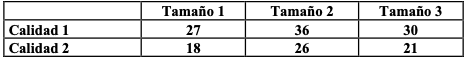

La de su planta B está dada por:

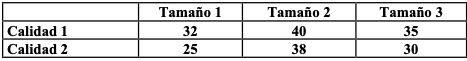

💠 Paso 1

---
Representamos matricialmente la producción de cintas en cada planta


In [ ]:
# Matriz de producción Planta A
produccion_A = np.array([
    [27, 36, 30],  # Calidad 1
    [18, 26, 21]   # Calidad 2
])

In [ ]:
# Matriz de producción Planta B
produccion_B = np.array([
    [32, 40, 35],  # Calidad 1
    [25, 38, 30]   # Calidad 2
])

In [ ]:
#Vemos cómo quedaron ambas matrices
print("Producción Planta A (en miles):\n", produccion_A)
print("\nProducción Planta B (en miles):\n", produccion_B)

💠 Paso 2

---
Calculamos la producción conjunta sumando ambas matrices


In [ ]:
# Suma matricial
produccion_total = produccion_A + produccion_B

print("\nProducción total A + B (en miles):\n", produccion_total)

💠 Paso 3

---
Hacemos una proyección para la apertura de una planta C sabiendo que la misma tendrá 1.5 veces la capacidad de la planta A.

Entonces calculamos la producción para la planta C (haciendo una multiplicación de la matriz de la planta A por el escalar 1.5)


In [ ]:
# Cálculo de producción para planta C
produccion_C = 1.5 * produccion_A

print("Producción proyectada Planta C (en miles):\n", produccion_C)

💠 Paso 4

---
Sumamos la producción de las 3 plantas ➡(A+B)+C


In [ ]:
# Producción total
produccion_total_tres_plantas = produccion_total + produccion_C

print("Producción total A + B + C (en miles):\n", produccion_total_tres_plantas)


⏩ También podemos calcular algunos indicadores clave para la gestión

In [ ]:
# 1. Producción total por calidad
#Para hacerlo sumamos los elementos de la matriz por filas
total_calidad = np.sum(produccion_total_tres_plantas, axis=1)
print("\nTotal producción por calidad (en miles):")
print(f"- Calidad 1: {total_calidad[0]} unidades")# la primer fila representa la calidad 1 - para python es posición 0
print(f"- Calidad 2: {total_calidad[1]} unidades")# la segunda fila representa la calidad 2 - posición 1

In [ ]:
# 2. Producción total por tamaño
#Para hacerlo sumamos los elementos de la matriz por columnas
total_tamano = np.sum(produccion_total_tres_plantas, axis=0)
print("\nTotal producción por tamaño (en miles):")
print(f"- Tamaño 1: {total_tamano[0]} unidades")# la primer columna representa el tamaño 1 - para python es posición 0
print(f"- Tamaño 2: {total_tamano[1]} unidades")# la segunda columna representa el tamaño 2 - para python es posición 1
print(f"- Tamaño 3: {total_tamano[2]} unidades")# la tercer columna representa el tamaño 3 - para python es posición 2

In [ ]:
# 3. Pocentaje de cada planta en la producción total
porcentaje_A = np.sum(produccion_A) / np.sum(produccion_total_tres_plantas) * 100
porcentaje_B = np.sum(produccion_B) / np.sum(produccion_total_tres_plantas) * 100
porcentaje_C = np.sum(produccion_C) / np.sum(produccion_total_tres_plantas) * 100

print("\nParticipación de cada planta en la producción total:")
print(f"- Planta A: {porcentaje_A:.2f}%")
print(f"- Planta B: {porcentaje_B:.2f}%")
print(f"- Planta C: {porcentaje_C:.2f}%")

⏩ Podemos visualizar los resultados con gráficos sencillos de barras

In [ ]:
#importamos la librería que nos permite graficar
import matplotlib.pyplot as plt

# Configuramos los gráficos

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Producción por calidad
calidades = ['Calidad 1', 'Calidad 2']
ax1.bar(calidades, total_calidad, color=['violet', 'orange'])
ax1.set_title('Producción Total por Calidad')
ax1.set_ylabel('Unidades (miles)')


# Gráfico 2: Producción por tamaño
tamanos = ['Tamaño 1', 'Tamaño 2', 'Tamaño 3']
ax2.bar(tamanos, total_tamano, color=['green', 'red', 'violet'])
ax2.set_title('Producción Total por Tamaño')
ax2.set_ylabel('Unidades (miles)')

plt.tight_layout()
plt.show()

⏩  Si la empresa decide aumentar la producción en la Planta B en un 20% y reducir la Planta A en un 10%:
1. Calcular las nuevas matrices de producción
2. Determinar el nuevo total de producción
3. Analizar cómo cambia la participación de cada planta

💠 Paso 1

---
Armamos las nuevas matrices de producción


In [ ]:
# Nuevas matrices
nueva_A = produccion_A * 0.9
nueva_B = produccion_B * 1.2

In [ ]:
#vemos las matrices
nueva_A

In [ ]:
nueva_B

💠 Paso 2

---

Calculamos la nueva producción total sumando matrices

In [ ]:
# Calculamos la nueva producción total
nueva_produccion_total = nueva_A + nueva_B + produccion_C

print("Nueva producción total (en miles):\n", nueva_produccion_total)

💠 Paso 3

---
Vemos los cambios en a participación de cada planta



In [ ]:
# 3. Pocentaje de cada planta en la producción total
porcentaje_nueva_A = np.sum(nueva_A) / np.sum(nueva_produccion_total) * 100
porcentaje_nueva_B = np.sum(nueva_B) / np.sum(nueva_produccion_total) * 100
porcentaje_nueva_C = np.sum(produccion_C) / np.sum(nueva_produccion_total) * 100

print("\nParticipación de cada planta en la producción total:")
print(f"- Planta A: {porcentaje_nueva_A:.2f}%")
print(f"- Planta B: {porcentaje_nueva_B:.2f}%")
print(f"- Planta C: {porcentaje_nueva_C:.2f}%")

⏩ Conclusiones del ejercicio

---

✅ Las operaciones matriciales son muy útiles para modelar problemas de producción

✅ Python permite realizar cálculos complejos de manera sencilla

✅ Podemos extraer información valiosa para la toma de decisiones

Fuentes:

Notas de álgebra teórico-prácticas: cátedra de Álgebra / Alicia Delia Fraquelli;Andrea Leonor Gache. - 1a ed. - Ciudad Autónoma de Buenos Aires: Universidad de Buenos Aires. Facultad de Ciencias Económicas, 2019.

Hilpisch, Y. (2018). Python for Finance: Mastering Data-Driven Finance (2nd ed.). O’Reilly Media.

---
# 📝 Ejercicios

> 💡 En todos: **antes de correr el código, escribí qué forma esperás que tenga el resultado**
> (cuántas filas, cuántas columnas). Después comprobalo con `.shape`. Es la mejor costumbre que te
> podés llevar de esta clase: la mitad de los errores con matrices son de forma, no de cuentas.

### ✅ Ejercicio 1 — Vectores

Las ventas de una sucursal durante seis meses fueron:

```python
ventas = np.array([420, 445, 470, 505, 530, 545])
```

1. ¿Cuántos elementos tiene? ¿Qué devuelve `ventas.shape` y por qué tiene esa forma rara con la coma?
2. Calculá el total del semestre, el promedio mensual y el mejor mes.
3. Aplicá un aumento del 12% a todos los meses **en una sola línea**, sin usar un ciclo.
4. Calculá la variación mes a mes con `np.diff()`. ¿Cuántos elementos tiene el resultado?
   ¿Por qué **uno menos**?

In [ ]:
import numpy as np

ventas = np.array([420, 445, 470, 505, 530, 545])

# Tu código acá

### ✅ Ejercicio 2 — `axis`: la pregunta que confunde a todo el mundo

Una empresa tiene tres sucursales y cuatro meses de ventas:

```python
ventas = np.array([
    [120, 135, 150, 145],   # Centro
    [ 95,  88, 102, 110],   # Norte
    [145, 160, 158, 172],   # Sur
])
```

1. ¿Qué forma tiene la matriz? ¿Qué representa cada dimensión?
2. Calculá el **total por sucursal**. ¿Va `axis=0` o `axis=1`?
3. Calculá el **total por mes**.
4. Calculá el **promedio de cada sucursal** y decí cuál rinde mejor.
5. **La trampa:** ¿qué devuelve `ventas.sum()` sin ningún `axis`? ¿En qué caso te sirve ese número?

In [ ]:
ventas = np.array([
    [120, 135, 150, 145],   # Centro
    [ 95,  88, 102, 110],   # Norte
    [145, 160, 158, 172],   # Sur
])

# Tu código acá

### ✅ Ejercicio 3 — `*` contra `@`: el error más caro

Una fábrica produce tres productos. Esta matriz dice **cuántas unidades** de cada insumo lleva cada
producto:

| | Madera | Tornillos | Pintura |
|---|---|---|---|
| **Silla** | 3 | 12 | 1 |
| **Mesa** | 8 | 20 | 2 |
| **Estante** | 5 | 16 | 1 |

Y los insumos cuestan: madera \$ 4.500, tornillos \$ 120, pintura \$ 2.800.

1. Armá la matriz `insumos` (3×3) y el vector `precios` (3 elementos).
2. Calculá el **costo de fabricar una unidad de cada producto**. ¿Va `*` o `@`? Pensalo antes.
3. Probá **las dos** operaciones y mirá qué forma devuelve cada una. ¿Qué está calculando `*`?
4. Si la empresa fabrica 40 sillas, 15 mesas y 25 estantes, ¿cuál es el **costo total**?
5. ¿Cuántas unidades de cada insumo necesita comprar para esa producción?

In [ ]:
# Tu código acá

### ✅ Ejercicio 4 — Matrices especiales

1. Creá una **matriz identidad** de 4×4 con `np.eye(4)`.
2. Multiplicá por ella la matriz de ventas del Ejercicio 2 (¡cuidado con las formas!) y verificá que
   no cambia nada. ¿Por qué la identidad es "el 1" de las matrices?
3. Creá una **matriz diagonal** con `np.diag([1.10, 1.05, 1.20])`, que representa un aumento
   distinto para cada sucursal.
4. Aplicásela a las ventas para que **cada sucursal reciba su propio aumento**. Verificá que Centro
   subió 10%, Norte 5% y Sur 20%.
5. **Verificá una propiedad, no la supongas:** comprobá con código que $(A^T)^T = A$.

In [ ]:
# Tu código acá

---
### 🎯 Ejercicio integrador — "Metalúrgica del Plata"

Una metalúrgica fabrica **tres productos** en **dos plantas**. La producción mensual es:

| Planta A | Perfiles | Chapas | Tubos |
|---|---|---|---|
| **Producción** | 320 | 180 | 240 |

| Planta B | Perfiles | Chapas | Tubos |
|---|---|---|---|
| **Producción** | 410 | 95 | 300 |

Cada producto requiere estas horas de trabajo y kilos de acero por unidad:

| | Horas | Acero (kg) |
|---|---|---|
| **Perfiles** | 1.5 | 8 |
| **Chapas** | 2.0 | 12 |
| **Tubos** | 1.2 | 6 |

La hora de trabajo cuesta \$ 4.800 y el kilo de acero \$ 950.

**Se pide:**

1. Armá la matriz de producción (2 plantas × 3 productos) y la de requerimientos (3 productos × 2 recursos).
2. Calculá, con **una sola operación matricial**, cuántas horas y cuántos kilos de acero consume
   cada planta. ¿Qué forma tiene el resultado y por qué?
3. Calculá el **costo total de cada planta**.
4. ¿Qué **participación** tiene cada planta en el costo total? (en porcentaje)
5. La empresa quiere **aumentar la producción de la Planta B un 15%** y **reducir la de A un 10%**.
   Armá las nuevas matrices y calculá el nuevo costo total.
6. **La pregunta de gestión:** el gerente dice que "la Planta B es más eficiente porque produce más
   unidades". Con los números en la mano, ¿es un buen argumento? ¿Qué medirías vos para comparar
   dos plantas?

> 📌 Se evalúa que las **formas de las matrices** estén bien pensadas (el punto 2 no sale si están
> al revés) y, sobre todo, **la respuesta al punto 6**.

In [ ]:
import numpy as np

# 1) Las matrices
produccion = np.array([
    [320, 180, 240],    # Planta A
    [410,  95, 300],    # Planta B
])

# Tu código acá

---
## 🧭 Para llevarse

| Concepto | Comando |
|---|---|
| Crear un array | `np.array(lista)` |
| Matriz de ceros / unos / identidad | `np.zeros((f,c))` · `np.ones((f,c))` · `np.eye(n)` |
| Forma de la tabla | `A.shape` → `(filas, columnas)` |
| Total por columna / por fila | `A.sum(axis=0)` · `A.sum(axis=1)` |
| Multiplicar celda a celda | `A * B` |
| **Producto matricial** | `A @ B` |
| Transponer | `A.T` |
| Diagonal | `np.diag(v)` |
| Comparar matrices | `np.allclose(A, B)` — **nunca `==`** |

**Las tres ideas de la clase:**
1. **Vectorizar** es decir qué hacer con todos los datos, no cómo recorrerlos.
2. `axis` indica **qué eje desaparece**: `axis=0` colapsa filas, `axis=1` colapsa columnas.
3. `*` y `@` son operaciones **distintas** y ninguna avisa cuando elegiste mal.

En la próxima clase usamos todo esto para resolver sistemas de ecuaciones.